In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal

In [2]:
class State(TypedDict):
    a : int
    b : int
    c : int

    equation : str
    determinant : float
    result : str

In [5]:
def get_equation(state : State):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {"equation": equation}

def calculate_determinant(state : State):
    determinant = state['b']**2 - 4*state['a']*state['c']
    return {"determinant": determinant}

def real_roots(state : State):
    root1 = (-state['b'] + state['determinant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['determinant']**0.5) / (2*state['a']) 

    rez = f"The roots are: {root1} and {root2}"
    return {"result": rez}

def repeated_roots(state : State):
    root = -state['b'] / (2*state['a'])
    rez = f"The root is: {root}"
    return {"result": rez}

def non_real_roots(state : State):
    rez = "The equation has no real roots."
    return {"result": rez}

def check_condition(state : State) -> Literal["real_roots", "repeated_roots", "non_real_roots"]:
    if state['determinant'] > 0:
        return "real_roots"
    elif state['determinant'] == 0:
        return "repeated_roots"
    else:
        return "non_real_roots"

In [6]:
graph = StateGraph(State)

graph.add_node("get_equation", get_equation)
graph.add_node("calculate_determinant", calculate_determinant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("non_real_roots", non_real_roots)

graph.add_edge(START, "get_equation")
graph.add_edge("get_equation", "calculate_determinant")
graph.add_conditional_edges("calculate_determinant", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("non_real_roots", END)

workflow = graph.compile()

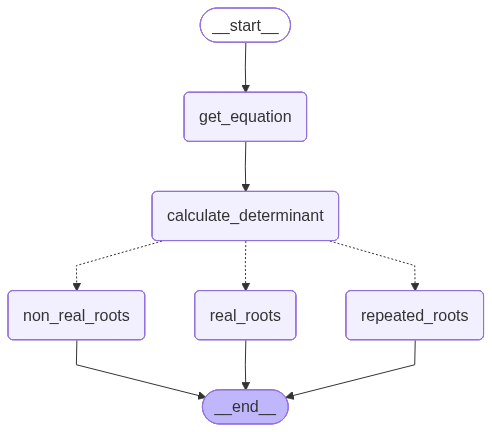

In [7]:
workflow

In [ ]:
input_state = {'a': 2, 'b': 4, 'c': 2}
output_state = workflow.invoke(input_state) # type:ignore

In [11]:
print(output_state)

{'a': 2, 'b': 4, 'c': 2, 'equation': '2x^2 + 4x + 2 = 0', 'determinant': 0, 'result': 'The root is: -1.0'}


In [12]:
print(f"a: {output_state['a']}")
print(f"b: {output_state['b']}")
print(f"c: {output_state['c']}")
print('-'*20)
print(f"Equation: {output_state['equation']}")
print('-'*20)
print(f"Determinant: {output_state['determinant']}")
print('-'*20)
print(f"Result: {output_state['result']}")


a: 2
b: 4
c: 2
--------------------
Equation: 2x^2 + 4x + 2 = 0
--------------------
Determinant: 0
--------------------
Result: The root is: -1.0
